In [33]:
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Librerías listas')

Librerías listas


In [34]:
gse = GEOparse.get_GEO(
    geo='gse2034',
    destdir='./datos_geo'
)

print('Dataset descargado')
print(f'Muestras: {len(gse.gsms)}')
print(f'Título: {gse.metadata["title"][0]}')

01-May-2026 18:56:22 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz to ./datos_geo\GSE2034_family.soft.gz
100%|█████████████████████████████████████████████████████████████████████████████| 62.2M/62.2M [00:06<00:00, 9.79MB/s]
01-May-2026 18:56:29 DEBUG downloader - Size validation passed
01-May-2026 18:56:29 DEBUG downloader - Moving C:\Users\iselo\AppData\Local\Temp\tmpxrlbvvnd to C:\Users\iselo\OneDrive\Escritorio\bioinfo-portfolio\datos_geo\GSE2034_family.soft.gz
01-May-2026 18:56:29 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/GSE2034_family.soft.gz
01-May-2026 18:56:29 INFO GEOparse - Parsing ./datos_geo\GSE2034_family.soft.gz: 
01-May-2026 18:56:29 DEBUG GEOparse - DATABASE: GeoMiame
01-May-2026 18:56:29 DEBUG GEOparse - SERIES: GSE2034
01-May-2026 18:56:30 DEBUG GEOparse - PLATFORM: GPL96
01-May-2026 18:56:33 DEBUG GEOparse - SAMPLE: GSM36777
01-May-2026 18:56:

Dataset descargado
Muestras: 286
Título: Breast cancer relapse free survival


In [35]:
pivot = gse.pivot_samples('VALUE')

print('=== Matriz de expresión ===')
print(f'Genes (filas):    {pivot.shape[0]}')
print(f'Muestras (cols):  {pivot.shape[1]}')
print(f'Valores faltantes: {pivot.isnull().sum().sum()}')
print()
print('Primeros 5 genes, 3 muestras:')
print(pivot.iloc[:5, :3])

=== Matriz de expresión ===
Genes (filas):    22283
Muestras (cols):  286
Valores faltantes: 0

Primeros 5 genes, 3 muestras:
name       GSM36777  GSM36778  GSM36779
ID_REF                                 
1007_s_at    3848.1    6520.9    5285.7
1053_at       228.9     112.5     178.4
117_at        213.1     189.8     269.7
121_at       1009.4    2083.3    1203.4
1255_g_at      31.8     145.8      42.5


In [45]:
# Verificar escala
print(f'Mediana actual: {pivot.median().median():.2f}')
print(f'Valor máximo:   {pivot.values[~np.isnan(pivot.values)].max():.2f}')
print()

# Aplicar log2 si los datos están en escala lineal
if pivot.median().median() > 50:
    print('Datos en escala lineal — aplicando log2...')
    pivot = pivot.where(pivot > 0, other=np.nan)
    pivot = np.log2(pivot)
    print(f'Mediana tras log2: {pivot.median().median():.2f}')
    print('Listo')
else:
    print('Ya están en log2 — no se necesita transformación')

Mediana actual: 239.10
Valor máximo:   157291.80

Datos en escala lineal — aplicando log2...
Mediana tras log2: 7.90
Listo


In [46]:
metadata_lista = []

for gsm_name, gsm in gse.gsms.items():
    info = gsm.metadata
    fila = {'sample_id': gsm_name}
    
    for key, val in info.items():
        if val:
            fila[key] = val[0]
    
    metadata_lista.append(fila)

df_meta = pd.DataFrame(metadata_lista)

print(f'Muestras con metadata: {len(df_meta)}')
print(f'Columnas disponibles: {list(df_meta.columns[:8])}')
print()
print(df_meta[['sample_id','title','source_name_ch1']].head())

Muestras con metadata: 286
Columnas disponibles: ['sample_id', 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count']

  sample_id              title source_name_ch1
0  GSM36777    Wang4812_JA_277          Breast
1  GSM36778    Wang4813_JA_278          Breast
2  GSM36779   Wang4630_JA798@C          Breast
3  GSM36780  Wang4889_JA_846@2          Breast
4  GSM36781  Wang4857_JA_765@2          Breast


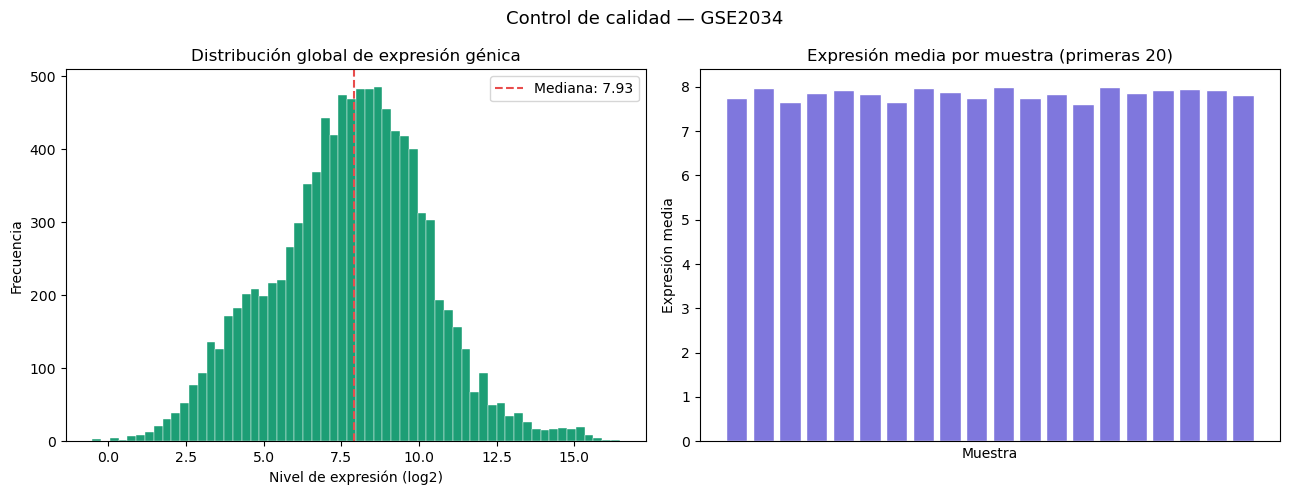

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

expresion_flat = pivot.values.flatten()
expr_sample = np.random.choice(expresion_flat, 10000)

axes[0].hist(expr_sample, bins=60, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribución global de expresión génica')
axes[0].set_xlabel('Nivel de expresión (log2)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(np.median(expr_sample), color='#E84C4C', linestyle='--', label=f'Mediana: {np.median(expr_sample):.2f}')
axes[0].legend()

muestras_ejemplo = pivot.columns[:20]
medias = pivot[muestras_ejemplo].mean()
axes[1].bar(range(len(medias)), medias, color='#7F77DD', edgecolor='white')
axes[1].set_title('Expresión media por muestra (primeras 20)')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Expresión media')
axes[1].set_xticks([])

plt.suptitle('Control de calidad — GSE2034', fontsize=13)
plt.tight_layout()
plt.savefig('geo_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
stats_genes = pd.DataFrame({
    'media':   pivot.mean(axis=1),
    'std':     pivot.std(axis=1),
    'mediana': pivot.median(axis=1),
    'rango':   pivot.max(axis=1) - pivot.min(axis=1)
})

print(f'Total genes: {len(stats_genes)}')
print()
print('Top 10 genes más variables:')
print(stats_genes.nlargest(10, 'std')[['media','std','rango']].round(3))

Total genes: 22283

Top 10 genes más variables:
            media    std   rango
ID_REF                          
206799_at   8.959  3.704  13.196
205916_at   6.618  3.546  13.553
206378_at  10.813  3.335  13.967
209728_at   6.765  3.299  11.027
203290_at   8.092  3.225  11.396
207802_at   4.684  3.199  15.163
209173_at  11.567  3.182  12.439
214451_at   8.465  3.180  12.109
205358_at   4.245  3.116  12.474
205979_at   7.573  3.097  13.806


In [49]:
umbral_std = stats_genes['std'].quantile(0.25)

pivot_filtrado = pivot[stats_genes['std'] > umbral_std]

print('=== Filtrado de genes ===')
print(f'Genes originales:  {pivot.shape[0]}')
print(f'Umbral std:        {umbral_std:.3f}')
print(f'Genes conservados: {pivot_filtrado.shape[0]}')
print(f'Genes eliminados:  {pivot.shape[0] - pivot_filtrado.shape[0]}')
print()
print('Eliminamos genes que no varían — son ruido, no información.')

=== Filtrado de genes ===
Genes originales:  22283
Umbral std:        0.547
Genes conservados: 16712
Genes eliminados:  5571

Eliminamos genes que no varían — son ruido, no información.


In [25]:
medias_muestras = pivot.mean()
stds_muestras = pivot.std()

media_global = medias_muestras.mean()
std_global = medias_muestras.std()

outliers = medias_muestras[
    (medias_muestras < media_global - 2*std_global) |
    (medias_muestras > media_global + 2*std_global)
]

print('=== Detección de outliers por muestra ===')
print(f'Media global de expresión: {media_global:.3f}')
print(f'Std global:                {std_global:.3f}')
print(f'Umbral inferior:           {media_global - 2*std_global:.3f}')
print(f'Umbral superior:           {media_global + 2*std_global:.3f}')
print()
if len(outliers) > 0:
    print(f'Muestras potencialmente problemáticas ({len(outliers)}):')
    print(outliers)
else:
    print('No se detectaron outliers extremos — dataset de buena calidad')

=== Detección de outliers por muestra ===
Media global de expresión: 3773.911
Std global:                1633.447
Umbral inferior:           507.017
Umbral superior:           7040.805

Muestras potencialmente problemáticas (13):
name
GSM36794    10419.675
GSM36828     8292.830
GSM36850     7980.005
GSM36900     8354.775
GSM36952     8679.325
GSM36972     8847.670
GSM36976     8450.430
GSM37029     7351.270
GSM37041     7412.305
GSM37050     8597.900
GSM37052     7337.550
GSM37053    11213.465
GSM37055     7662.910
dtype: float64


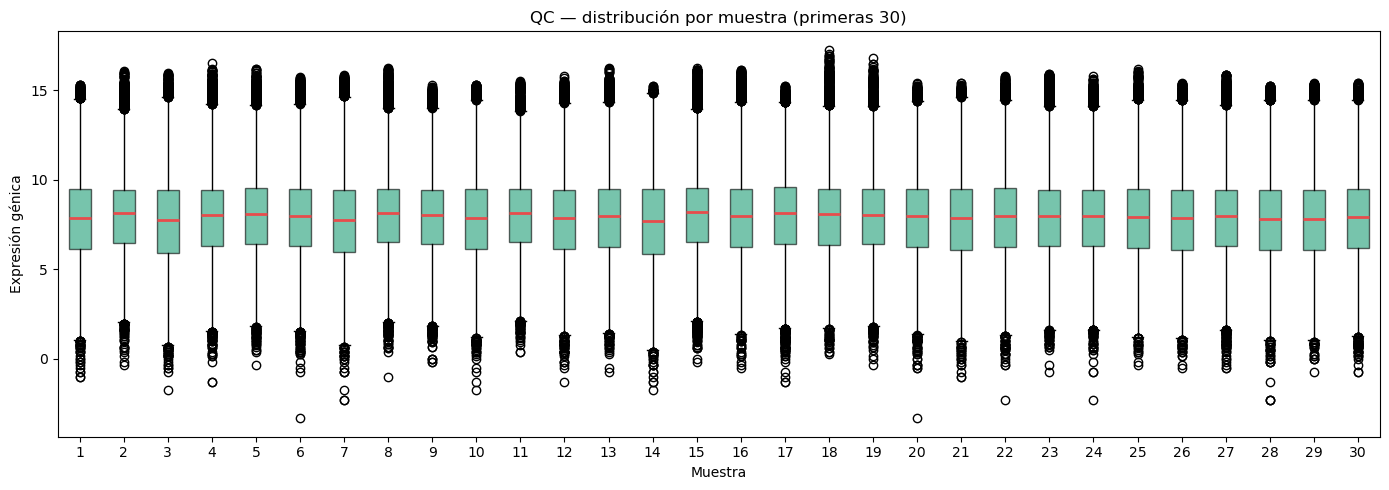

In [50]:
muestras_qc = pivot.columns[:30]
data_qc = pivot[muestras_qc]

fig, ax = plt.subplots(figsize=(14, 5))

ax.boxplot(
    [data_qc[col].dropna() for col in data_qc.columns],
    patch_artist=True,
    boxprops=dict(facecolor='#1D9E75', alpha=0.6),
    medianprops=dict(color='#E84C4C', linewidth=2)
)

ax.set_xlabel('Muestra')
ax.set_ylabel('Expresión génica')
ax.set_title('QC — distribución por muestra (primeras 30)')

plt.tight_layout()
plt.savefig('qc_boxplot.png', dpi=150)
plt.show()

In [51]:
pivot_filtrado.to_csv('expresion_filtrada.csv')
df_meta.to_csv('metadata_clinica.csv', index=False)

print('=== Archivos guardados ===')
print(f'expresion_filtrada.csv — {pivot_filtrado.shape[0]} genes × {pivot_filtrado.shape[1]} muestras')
print(f'metadata_clinica.csv   — {len(df_meta)} pacientes × {len(df_meta.columns)} variables clínicas')
print()
print('Estos archivos los usarás el miércoles para el análisis diferencial.')

=== Archivos guardados ===
expresion_filtrada.csv — 16712 genes × 286 muestras
metadata_clinica.csv   — 286 pacientes × 28 variables clínicas

Estos archivos los usarás el miércoles para el análisis diferencial.
